In [1]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from datetime import timedelta
import matplotlib.dates as mdates
from scipy import interpolate, integrate
from pandas.tseries.frequencies import to_offset
import datetime

In [2]:
PATH_CLASS = '../../data/classification/'
PATH_RADAR = '../../data/radar/'
PATH_FIG = '../figures/'
PATH_MWR = '../../data/radar/'

In [3]:
import os
import pandas as pd

class Intersection_products:
    def __init__(self,
                 path_class,
                 path_radar):
       
        classification_files = {}
        for file in os.listdir(path_class):
            if file.endswith(".nc"):
                classification_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
       
        radar_files = {}
        for file in os.listdir(path_radar):
            if file.endswith(".nc"):
                radar_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
        
        #mwr_files = {}
        #for file in os.listdir(path_mwr):
        #    if file.endswith(".nc"):
        #        mwr_files[pd.to_datetime(file[:8], format = "%Y%m%d")] = file
                
        classSet = set(classification_files)
        radarSet = set(radar_files)
        #mwrSet   = set(mwr_files)

        intersec_products = [] 
        for date in classSet.intersection(radarSet):
            intersec_products.append(date)
    
        self.radar_files          = radar_files  # dict 
        self.classification_files = classification_files # dict
        self.dates                = sorted(intersec_products)
        
class HMmodel:
    def __init__(self,
                 lwp,
                 h,
                 z,
                 v=8.7,
                 rw=1e6):
        
        self.cloud_lwp = lwp # liquid water path
        self.cloud_z   = h   # cloud thickeness
        self.radar_ze  = z
        self.nu        = v
        self.rho_w     = rw
        self.k_nv      = (v+3)*(v+4)*(v+5)/( v*(v+1)*(v+2) ) 
        self.k_rv      = (v+2)/( (v+3)*(v+4)*(v+5) )**(1./3.)
        
    def get_num(self):
        # droplet concentration in cm^-3
        #print(integrate.trapz(np.sqrt(self.radar_ze), self.cloud_z))
        # ( g m^-2 / ( g m^-3 mm^3 m^-3/2 * m )  )^2 
        # ( m^3/2 mm^-3 )^2
        #  m^3 (10^-3 m)^-6
        #  m^3 10^-18 m^-6 
        # 10-18 m^-3
        # um^-3
        # To convert from um^-3 to cm^-3: 10^12 * (um^-3) = cm^-3
        return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z) ) )**2
        #return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.nansum(np.sqrt(self.radar_ze))*30 ) )**2
    
    def get_re(self):
        # (  g m^-3 mm^3 m^-3/2 * m / ( g m^-2)  )^1/3 mm m^-1/3
        # (  mm^3 m^-3/2  )^1/3 mm m^-1/2
        # (  mm m^-1/2  ) mm m^-1/2
        # (  mm^2 m^-1
        # (  10^-6 m^2 m^-1 )
        # ( 10^-6 m ) = um
        #print(  ( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z)/(48*self.cloud_lwp) )**(1./3.) * self.radar_ze**(1./6.)  ) 
        return self.k_rv*( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z)/(48*self.cloud_lwp) )**(1./3.) * self.radar_ze**(1./6.)
        

In [4]:
cloudnet_example = Intersection_products(PATH_CLASS, PATH_RADAR)
start_date       = min(cloudnet_example.dates)
end_date         = max(cloudnet_example.dates)

for date in cloudnet_example.dates:
    print(date.date(), cloudnet_example.radar_files[date])
    
#res = (cloudnet_example.dates == pd.Timestamp('2021-04-25')).argmax()

2021-04-01 20210401_granada_rpg-fmcw-94.nc
2021-04-02 20210402_granada_rpg-fmcw-94.nc
2021-04-03 20210403_granada_rpg-fmcw-94.nc
2021-04-04 20210404_granada_rpg-fmcw-94.nc
2021-04-05 20210405_granada_rpg-fmcw-94.nc
2021-04-06 20210406_granada_rpg-fmcw-94.nc
2021-04-07 20210407_granada_rpg-fmcw-94.nc
2021-04-08 20210408_granada_rpg-fmcw-94.nc
2021-04-09 20210409_granada_rpg-fmcw-94.nc
2021-04-10 20210410_granada_rpg-fmcw-94.nc
2021-04-11 20210411_granada_rpg-fmcw-94.nc
2021-04-12 20210412_granada_rpg-fmcw-94.nc
2021-04-14 20210414_granada_rpg-fmcw-94.nc
2021-04-15 20210415_granada_rpg-fmcw-94.nc
2021-04-16 20210416_granada_rpg-fmcw-94.nc
2021-04-17 20210417_granada_rpg-fmcw-94.nc
2021-04-18 20210418_granada_rpg-fmcw-94.nc
2021-04-19 20210419_granada_rpg-fmcw-94.nc
2021-04-21 20210421_granada_rpg-fmcw-94.nc
2021-04-22 20210422_granada_rpg-fmcw-94.nc
2021-04-23 20210423_granada_rpg-fmcw-94.nc
2021-04-24 20210424_granada_rpg-fmcw-94.nc
2021-04-25 20210425_granada_rpg-fmcw-94.nc
2021-04-26 

In [5]:
date_complete = pd.date_range( start=start_date, end=end_date )
i = 0
for date in date_complete:
    if date == cloudnet_example.dates[i]:
        i+=1
        print(True)
        # Do the script
    else:
        print(False)
        # ADD NaN

True
True
True
True
True
True
True
True
True
True
True
True
False
True
True
True
True
True
True
False
True
True
True
True
True
True
True
True
True
True


In [6]:
date_ex        = cloudnet_example.dates[0] # 29/04/2021
# i = 20 case with diferent resolution 
radar          = nc.Dataset(PATH_RADAR+cloudnet_example.radar_files[date_ex])
classification = nc.Dataset(PATH_CLASS+cloudnet_example.classification_files[date_ex])

aux_t = []
for h in radar['time']:
    aux_t.append( cloudnet_example.radar_files[date_ex][:8] + ' ' + str(timedelta(hours=float(h))) )

time_radar = pd.to_datetime(aux_t, format = "%Y%m%d %H:%M:%S" ) 

aux_t = []
for h in classification['time']:
    aux_t.append( cloudnet_example.classification_files[date_ex][:8] + ' ' + str(timedelta(hours=float(h))) )

time_class = pd.to_datetime(aux_t, format = "%Y%m%d %H:%M:%S") 

In [8]:
radar.variables

{'file_code': <class 'netCDF4._netCDF4.Variable'>
 int32 file_code()
     units: 1
     long_name: File code
     comment: Indicates the RPG software version.
 unlimited dimensions: 
 current shape = ()
 filling off,
 'program_number': <class 'netCDF4._netCDF4.Variable'>
 int32 program_number()
     units: 1
     long_name: Program number
 unlimited dimensions: 
 current shape = ()
 filling off,
 'model_number': <class 'netCDF4._netCDF4.Variable'>
 int32 model_number()
     units: 1
     long_name: Model number
     definition: 
 0: Single polarisation radar.
 1: Dual polarisation radar.
 unlimited dimensions: 
 current shape = ()
 filling off,
 'radar_frequency': <class 'netCDF4._netCDF4.Variable'>
 float32 radar_frequency()
     units: GHz
     long_name: Radar transmit frequency
 unlimited dimensions: 
 current shape = ()
 filling off,
 'antenna_separation': <class 'netCDF4._netCDF4.Variable'>
 float32 antenna_separation()
     units: m
     long_name: Antenna separation
 unlimited 

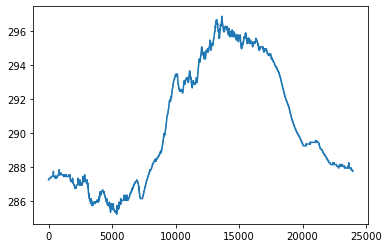

In [11]:
plt.figure()
plt.plot(radar['temperature'][:])
plt.show()

In [7]:
classification.dimensions

{'time': <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 2880,
 'height': <class 'netCDF4._netCDF4.Dimension'>: name = 'height', size = 380}

In [8]:
radar.dimensions

{'time': <class 'netCDF4._netCDF4.Dimension'>: name = 'time', size = 23961,
 'range': <class 'netCDF4._netCDF4.Dimension'>: name = 'range', size = 380,
 'chirp_sequence': <class 'netCDF4._netCDF4.Dimension'>: name = 'chirp_sequence', size = 4}

In [9]:
radar['range_resolution'][:]

masked_array(data=[29.811771, 29.811771, 29.811771, 51.10518 ],
             mask=False,
       fill_value=1e+20,
            dtype=float32)

In [10]:
print(time_radar[0])
print(time_radar[1])
print(type(time_radar))

2021-04-01 00:00:01
2021-04-01 00:00:04
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


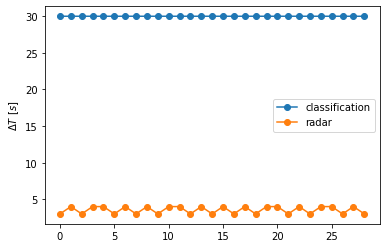

Timestamp('2021-04-01 03:00:22.000122')

In [11]:
a1 = np.diff(classification['time'][:30])*3600
a2 = np.diff(radar['time'][:30])*3600
#print(a1)
#print(a2)
plt.figure()
plt.plot(a1, '-o',label='classification')
plt.plot(a2, '-o', label='radar')
plt.ylabel(r'$\Delta T\ [s]$')
plt.legend()
plt.show()

time_radar[3000]

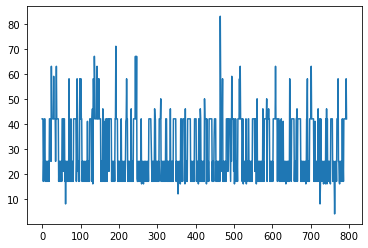

4 83


In [12]:
# Verification of how many time datapoints are equal in radar and classification data
ind = []
s = 0
for t in classification['time']:
    a = np.where(t==radar['time'])[0]
    if a.size > 0 and a.size == 1:
        ind.append(a[0]) #indexes of coincidency 
        #print("achou")
        s+=1
ind    = np.array(ind, int)
ind_dif=np.diff(ind)
plt.figure()
plt.plot(ind_dif)
plt.show()

print(min(ind_dif), max(ind_dif))

In [13]:
# Verification of how many time datapoints are equal in radar and classification data
s = 0
equal_time = []
for t in time_class:
    if t in time_radar:
        equal_time.append(t)
        s+=1
print("Equal time index (between class and radar) = %d"%(s))

Equal time index (between class and radar) = 795


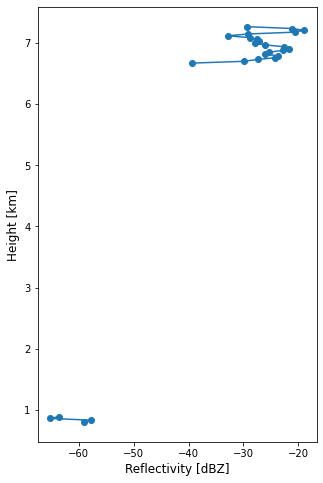

In [14]:
t = 3000
fig = plt.figure(figsize=[5, 8])
ax1 = plt.subplot()

colormesh = plt.plot(radar['Zh'][t,:], radar['height'][:]/1000, marker='o')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_size(12)
xlaby.set_size(12)
ax1.set_ylabel(r'Height [km]')
ax1.set_xlabel(r'Reflectivity [dBZ]')
plt.show()

-0.9179547 -46.003464 11.400086


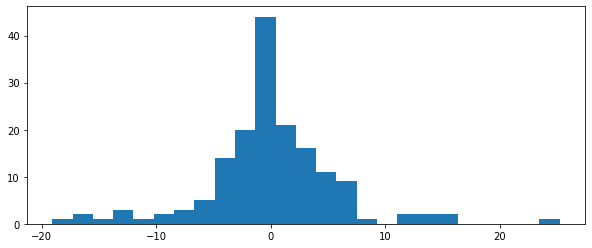

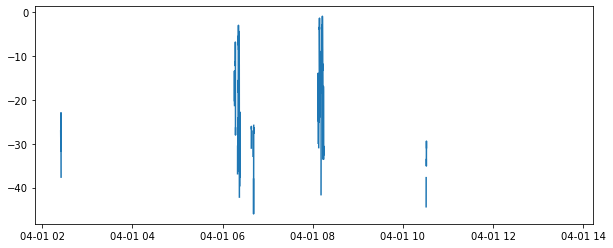

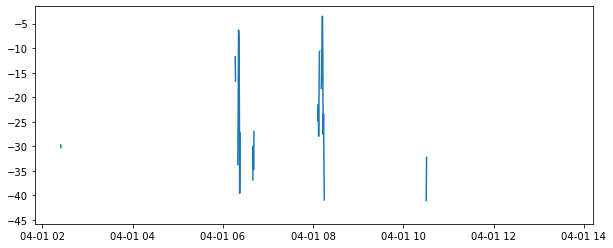

In [15]:
level = 4 #km
level_index = np.where(radar['height'][:]/1000 <= level)[0][-1]
df_test = pd.DataFrame( data=radar['Zh'][:, level_index], index=time_radar )
print(np.nanmax(df_test), np.nanmin(df_test), np.nanstd(df_test))

if df_test.diff().any(axis=None):
    plt.figure(figsize=[10, 4])
    plt.hist(df_test.diff(), bins=25)
    plt.show()
else:
    print("Theres no enough reflectivity data at "+str(level)+" km, only NaNs")
plt.figure(figsize=[10, 4])
plt.plot(df_test)
plt.show()

plt.figure(figsize=[10, 4])
plt.plot(df_test.resample('30s').mean()) # 1 min moving mean 
plt.show()

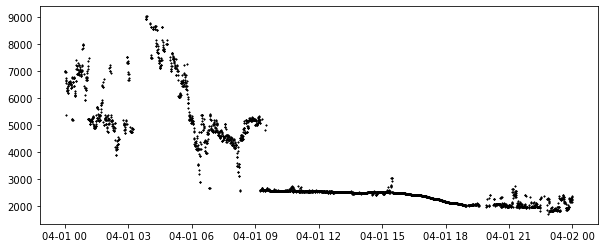

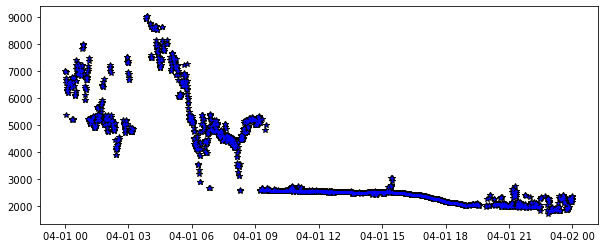

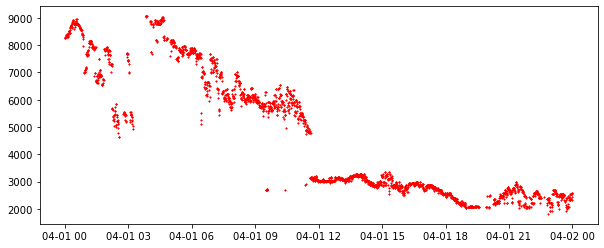

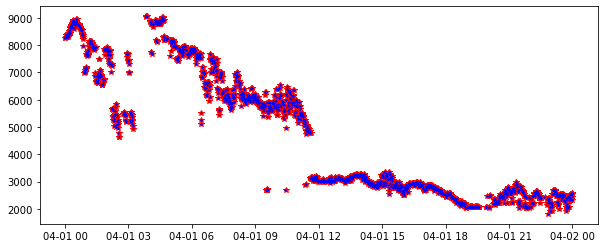

In [16]:
df_test2 = pd.DataFrame( data=classification['cloud_base_height_amsl'][:], index=time_class )
df_test3 = pd.DataFrame( data=classification['cloud_top_height_amsl'][:], index=time_class )

plt.figure(figsize=[10, 4])
plt.plot(df_test2, '*k', markersize=1.5)
plt.show()

plt.figure(figsize=[10, 4])
plt.plot(df_test2, '*', color='k')
plt.plot(df_test2.resample('30s').mean(), '*', color='b', markersize=1.5) # 1 min moving mean 
plt.show()

plt.figure(figsize=[10, 4])
plt.plot(df_test3, '*r', markersize=1.5)
plt.show()

plt.figure(figsize=[10, 4])
plt.plot(df_test3, '*', color='r')
plt.plot(df_test3.resample('30s').mean(), '*', color='b', markersize=1.5) # 1 min moving mean 
plt.show()



In [17]:
df_test4 = pd.DataFrame( data=radar['Zh'][:],
                         index=time_radar,
                         columns=radar['height'][:])
df_test4

,799.247070,829.058838,858.870605,888.682373,918.494141,948.305908,978.117676,1007.929443,1037.741211,1067.552979,...,13711.820312,13762.925781,13814.031250,13865.135742,13916.241211,13967.346680,14018.452148,14069.556641,14120.662109,14171.767578
2021-04-01 00:00:01.000000,-67.076996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01 00:00:04.000000,-60.563393,-59.660675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01 00:00:08.000000,-67.828400,-66.540733,-60.868546,-64.466568,-63.381451,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01 00:00:11.000000,-67.409554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01 00:00:15.000001,-65.367363,NaN,NaN,NaN,NaN,-56.974133,-60.321907,NaN,NaN,-58.727242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-01 23:59:44.001160,-50.290611,-40.490372,-43.335579,NaN,NaN,-55.173191,-55.416183,NaN,NaN,-60.195831,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01 23:59:47.997437,-24.739407,-49.205215,-51.118614,-55.989975,NaN,-56.667267,-39.437790,-37.441479,-44.374725,-41.169285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01 23:59:50.998077,-56.059277,-49.925259,-45.318302,-53.385124,NaN,NaN,NaN,NaN,NaN,-56.406174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-01 23:59:55.001221,NaN,NaN,NaN,NaN,-48.505074,-44.465103,-44.572498,-47.769421,-48.608139,-54.131645,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


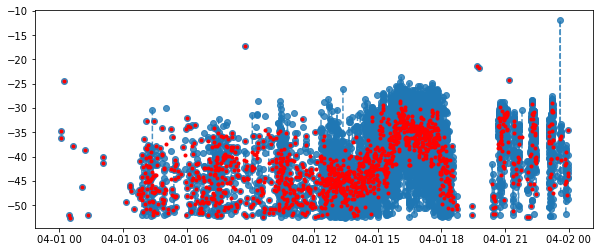

In [18]:
i = 50
average_time             = '30s'
dfnew_cb                 = pd.DataFrame(data=classification['cloud_base_height_amsl'][:], 
                                        index=time_class ).resample(average_time).mean()
dfnew_cb.index           = dfnew_cb.index + to_offset("15s")
dfnew_ct                 = pd.DataFrame(data=classification['cloud_top_height_amsl'][:],
                                        index=time_class ).resample(average_time).mean()
dfnew_ct.index           = dfnew_ct.index + to_offset("15s")
dfnew_reflectivity       = pd.DataFrame(data=radar['Zh'][:],
                                        index=time_radar,
                                        columns=radar['height'][:]).resample(average_time).mean()
dfnew_reflectivity.index = dfnew_reflectivity.index + to_offset("15s")
dfnew_lwp                = pd.DataFrame(data=radar['lwp'][:], 
                                        index=time_radar ).resample(average_time).mean()
dfnew_lwp.index          = dfnew_lwp.index + to_offset("15s")

#plt.figure(figsize=[12, 6])
plt.figure(figsize=[10, 4])
plt.plot(df_test4.iloc[:,i], '--o', alpha=.8) 
plt.plot(dfnew_reflectivity.iloc[:,i], '.', color="red")
plt.show()

In [19]:
fill_value = radar['Zh'][:].fill_value
radar_aux  = radar['Zh'][:].data
radar_aux[radar_aux==fill_value] = np.nan

radar_interp = np.zeros( (classification['time'].shape[0], radar['height'].shape[0]) )
for k in range(radar['height'].shape[0]):
    f    = interpolate.interp1d(radar['time'], radar_aux[:,k], kind='next', fill_value="extrapolate")
    radar_interp[:,k] = f(classification['time'])

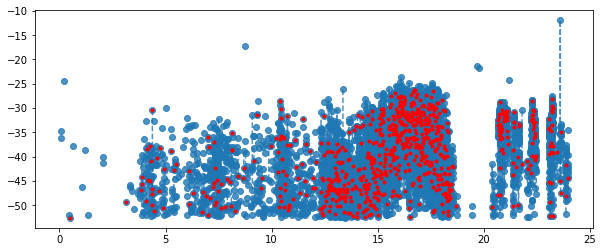

In [20]:
i = 50
plt.figure(figsize=[10, 4])
plt.plot(radar['time'], radar['Zh'][:,i], '--o', alpha=.8) 
plt.plot(classification['time'], radar_interp[:,i], '.', color="red")
plt.show()

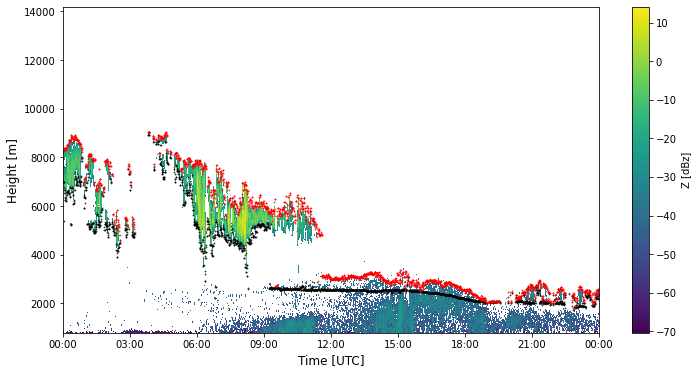

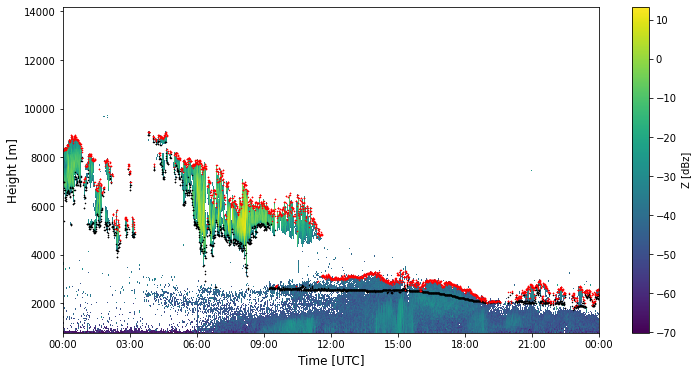

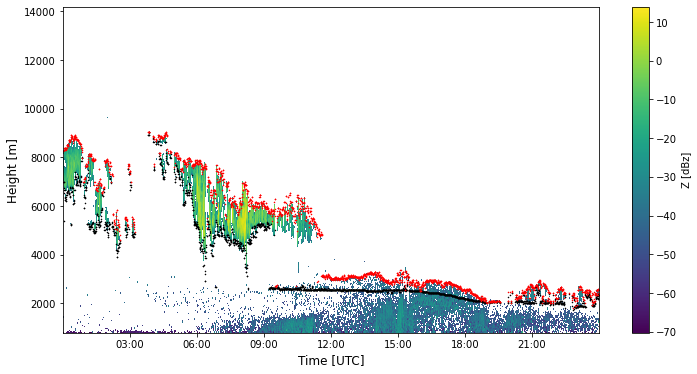

In [21]:
fig = plt.figure(figsize=[12, 6])
#fig = plt.figure()
ax1 = plt.subplot()

colormesh = plt.pcolormesh(time_radar, radar['height'][:], np.transpose(radar['Zh'][:]),
                          cmap='viridis',
                          shading='nearest')
plot1 = plt.scatter(time_class, classification['cloud_base_height_amsl'][:], s=1, c='black', alpha=.7, marker='*')
plot2 = plt.scatter(time_class, classification['cloud_top_height_amsl'][:], s=1, c='red', alpha=.7, marker='*')

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_size(12)
xlaby.set_size(12)
ax1.set_ylabel(r'Height [m]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Z [dBz]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()
#------------------------------------------------------------------------------------------

fig = plt.figure(figsize=[12, 6])
ax1 = plt.subplot()

colormesh          = plt.pcolormesh(dfnew_reflectivity.index, 
                                    dfnew_reflectivity.columns , 
                                    np.transpose(dfnew_reflectivity),
                                    cmap='viridis')
plot1 = plt.plot(dfnew_cb, "*", color='black', markersize=1.)
plot2 = plt.plot(dfnew_ct, "*", color='red', markersize=1.)

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_size(12)
xlaby.set_size(12)
ax1.set_ylabel(r'Height [m]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Z [dBz]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()
#------------------------------------------------------------------------------------------

fig = plt.figure(figsize=[12, 6])
ax1 = plt.subplot()

dfnew_cb_interp    = df_test2.copy()
dfnew_ct_interp    = df_test3.copy()
colormesh          = plt.pcolormesh(time_class, 
                                    classification['height'], 
                                    np.transpose(radar_interp),
                                    cmap='viridis')
plot1 = plt.plot(dfnew_cb_interp, "*", color='black', markersize=1.)
plot2 = plt.plot(dfnew_ct_interp, "*", color='red', markersize=1.)

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_size(12)
xlaby.set_size(12)
ax1.set_ylabel(r'Height [m]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Z [dBz]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()

## Rain and Drizzle points removing 

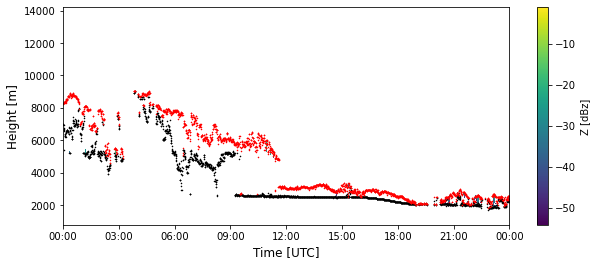

In [22]:
liquid_cloud = 1 # Cloud liquid droplets only
ze_liquid    = dfnew_reflectivity.where(classification['target_classification'][:]\
                                     == liquid_cloud, np.nan)

fig = plt.figure(figsize=[10, 4])
ax1 = plt.subplot()

colormesh          = plt.pcolormesh(ze_liquid.index, 
                                    ze_liquid.columns, 
                                    np.transpose(ze_liquid),
                                    cmap='viridis')
plot1 = plt.plot(dfnew_cb, "*", color='black', markersize=1.)
plot2 = plt.plot(dfnew_ct, "*", color='red', markersize=1.)

xlabx = ax1.xaxis.get_label()
xlaby = ax1.yaxis.get_label()
    
xlabx.set_size(12)
xlaby.set_size(12)
ax1.set_ylabel(r'Height [m]')
ax1.set_xlabel(r'Time [UTC]')
cbar = plt.colorbar(colormesh)
cbar.set_label(r'Z [dBz]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()

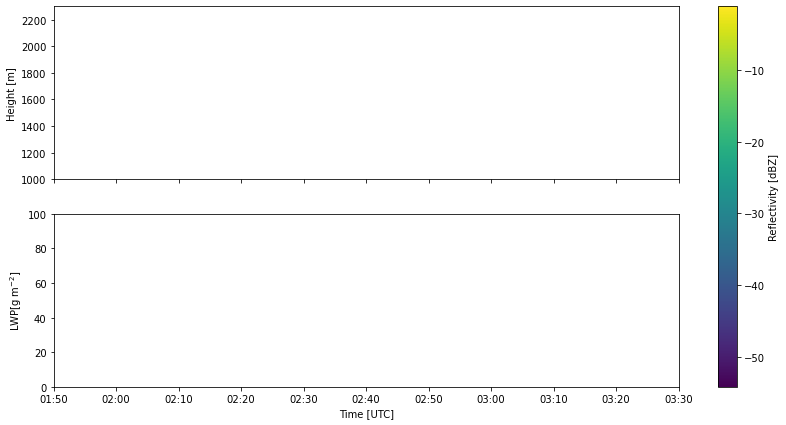

In [23]:
fig, axs = plt.subplots(2, sharex=True, figsize=(14, 7))

f1 = axs[0].pcolormesh(ze_liquid.index, 
                        ze_liquid.columns, 
                        np.transpose(ze_liquid),
                        cmap='viridis')
f2 = axs[0].plot(dfnew_cb, "*", color='black', markersize=10)
f3 = axs[0].plot(dfnew_ct, "*", color='red', markersize=10)

#xlabx = ax1.xaxis.get_label()
#xlaby = ax1.yaxis.get_label()

#xlabx.set_size(12)
#xlaby.set_size(12)
axs[0].set_ylabel(r'Height [m]')
fig.colorbar(f1, ax=axs[0:2],  label='Reflectivity [dBZ]')
#axs[0].set_xlim([datetime.datetime(2021, 4, 29, 1, 50), datetime.datetime(2021, 4, 29, 3, 30)])
axs[0].set_ylim([1000,2300])

f4 = axs[1].plot(dfnew_lwp, "*", color='black', markersize=10)

axs[1].set_ylabel(r'LWP[g m$^{-2}$]')
axs[1].set_xlabel(r'Time [UTC]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlim([datetime.datetime(2021, 4, 29, 1, 50), datetime.datetime(2021, 4, 29, 3, 30)])
axs[1].set_ylim([0,100])
#axs[1].set_position(axs[0].get_position())
#plt.savefig(PATH_FIG+cloudnet_filename[0][:8]+'_radar.png', dpi=400)
plt.show()


In [24]:
n_equal = sum(classification["height"][:] == radar["height"][:])
if n_equal == radar.dimensions["range"].size:
    print("Confirmed: range radar == range classification")
print("----------------------------------------------------------------")
i = 0
j = 0
for ind in ze_liquid.index:
    i_cbase = np.argmax(radar["height"][:] == dfnew_cb.loc[ind][0])
    i_ctop  = np.argmax(radar["height"][:] == dfnew_ct.loc[ind][0])
    if np.isnan(dfnew_cb.loc[ind][0]) and np.isnan(dfnew_ct.loc[ind][0]):
        i+=1
    elif dfnew_cb.loc[ind][0] == radar["height"][:][i_cbase] and dfnew_ct.loc[ind][0] == radar["height"][:][i_ctop]:
        j+=1
        
    #print("base = %f, base_radar = %f"%(dfnew_cb.loc[ind][0], radar["height"][:][i_cbase]))
    #print("base = %f, base_radar = %f"%(dfnew_cb.loc[ind][0], radar["height"][:][i_cbase]))
print("Base de la Nube: NaNs = %d, not NaNs = %d, Total = %d"%(i, j, i+j))
print(ze_liquid.shape[0])
print("----------------------------------------------------------------")
i_cbase = np.argmax(radar["height"][:] == dfnew_cb.loc['2021-04-29 00:00:15'][0])
i_ctop  = np.argmax(radar["height"][:] == dfnew_ct.loc['2021-04-29 00:00:15'][0])
print(dfnew_cb.loc['2021-04-29 00:00:15'][0], dfnew_ct.loc['2021-04-29 00:00:15'][0])
print(i_cbase, i_ctop)
print(radar["height"][:][i_cbase], radar["height"][:][i_ctop])
print("----------------------------------------------------------------")
z_cloud = ze_liquid.loc['2021-04-29 00:00:15'].iloc[i_cbase:i_ctop+1]
z_ex    = z_cloud[z_cloud.notnull()]
h_test  = z_cloud[z_cloud.notnull()].index.array
z_new   = 10**(z_ex/10)
print(z_ex)
print(h_test)
print( integrate.trapz(z_new**.5, h_test) )
print( np.trapz(z_new**.5, h_test) )

Confirmed: range radar == range classification
----------------------------------------------------------------
Base de la Nube: NaNs = 344, not NaNs = 2536, Total = 2880
2880
----------------------------------------------------------------


KeyError: '2021-04-29 00:00:15'

In [25]:
num_mh = pd.DataFrame(index=ze_liquid.index.array,
                      data=np.zeros(ze_liquid.shape[0])) # homogeneos mixing 
ref_mh = pd.DataFrame(data=np.zeros( (ze_liquid.shape[0], ze_liquid.shape[1])), 
                      index=ze_liquid.index.array, 
                      columns=radar["height"][:])  # homogeneos mixing
test = []
for ind in ze_liquid.index:
    i_cbase = np.argmax(radar["height"][:] == dfnew_cb.loc[ind][0]) 
    i_ctop  = np.argmax(radar["height"][:] == dfnew_ct.loc[ind][0]) 
    z_cloud = ze_liquid.loc[ind].iloc[i_cbase:i_ctop+1] # reflectivity inside the cloud [dBz]
    
    #Remove NaNs and convert Z from dBz to mm^6 m^-3:
    ze = 10**(z_cloud[z_cloud.notnull()]/10)
    
    #print(ze.index)
    #print(i_cbase, i_ctop)
    #print(10**(z_cloud[z_cloud.notnull()]/10))
    cloud_model               = HMmodel( dfnew_lwp.loc[ind][0],
                                        z_cloud[z_cloud.notnull()].index.array,
                                        ze )
    num_mh.loc[ind]           = cloud_model.get_num()
    ref_mh.loc[ind, ze.index] = cloud_model.get_re()
    #print(ref_mh.loc[ind, ze.index[:]])
    #test.append(cloud_model.get_re())
    #re = cloud_model.get_re()
    #ref_mh.loc[re.index, re.index.array] = 
    #print(num_mh.loc[ind])
    #print( cloud_model.get_re())
    #print( cloud_model.get_re().index.array )
num_mh.replace([np.inf, -np.inf], np.nan, inplace=True)
ref_mh.replace(0, np.nan, inplace=True)

/tmp/ipykernel_80262/767986050.py:62: RuntimeWarning: divide by zero encountered in double_scalars
  return 1e12*self.k_nv*( 6*self.cloud_lwp/( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z) ) )**2
/tmp/ipykernel_80262/767986050.py:73: RuntimeWarning: invalid value encountered in double_scalars
  return self.k_rv*( np.pi*self.rho_w*np.trapz(np.sqrt(self.radar_ze), self.cloud_z)/(48*self.cloud_lwp) )**(1./3.) * self.radar_ze**(1./6.)


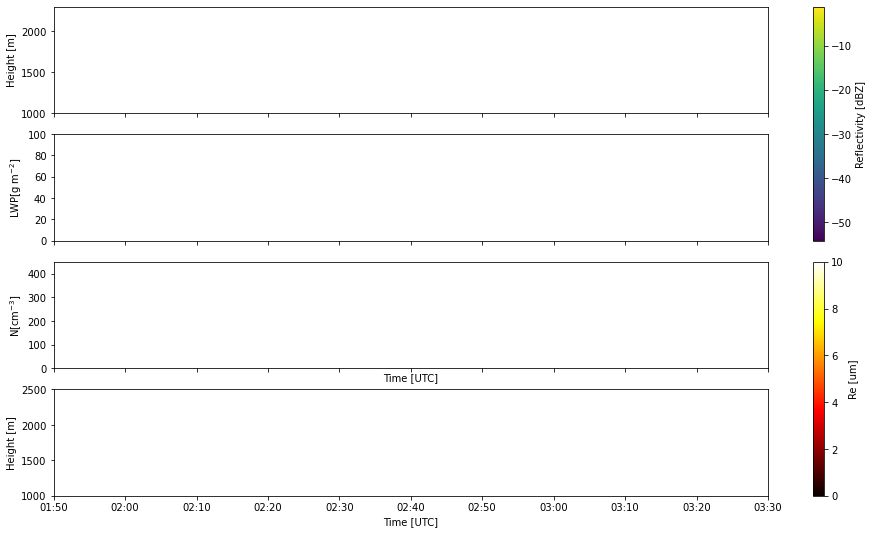

In [26]:
fig, axs = plt.subplots(4, sharex=True, figsize=(16, 9))

f1 = axs[0].pcolormesh(ze_liquid.index, 
                        ze_liquid.columns, 
                        np.transpose(ze_liquid),
                        cmap='viridis')
f2 = axs[0].plot(dfnew_cb, "*", color='black', markersize=10)
f3 = axs[0].plot(dfnew_ct, "*", color='red', markersize=10)

axs[0].set_ylabel(r'Height [m]')
fig.colorbar(f1, ax=axs[0:2],  label='Reflectivity [dBZ]')
axs[0].set_ylim([1000,2300])

f4 = axs[1].plot(dfnew_lwp, "s-", color='magenta', markersize=5, markerfacecolor='magenta')

axs[1].set_ylabel(r'LWP[g m$^{-2}$]')
axs[1].set_ylim([0,100])

f5 = axs[2].plot(num_mh, "-s", color='blue', markersize=5)

axs[2].set_ylabel(r'N[cm$^{-3}$]')
axs[2].set_xlabel(r'Time [UTC]')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2].set_xlim([datetime.datetime(2021, 4, 29, 1, 50), datetime.datetime(2021, 4, 29, 3, 30)])
axs[2].set_ylim([0,450])

f6 = axs[3].pcolormesh(ref_mh.index, 
                    ref_mh.columns, 
                    np.transpose(ref_mh),
                    cmap='hot',
                    vmin=0,
                    vmax=10)

axs[3].set_ylabel(r'Height [m]')
axs[3].set_xlabel(r'Time [UTC]')
fig.colorbar(f6, ax=axs[2:4], label='Re [um]')
#axs.set_ylim([1000,2300])
axs[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3].set_xlim([datetime.datetime(2021, 4, 29, 1, 50), datetime.datetime(2021, 4, 29, 3, 30)])
axs[3].set_ylim([1000,2500])
plt.show()

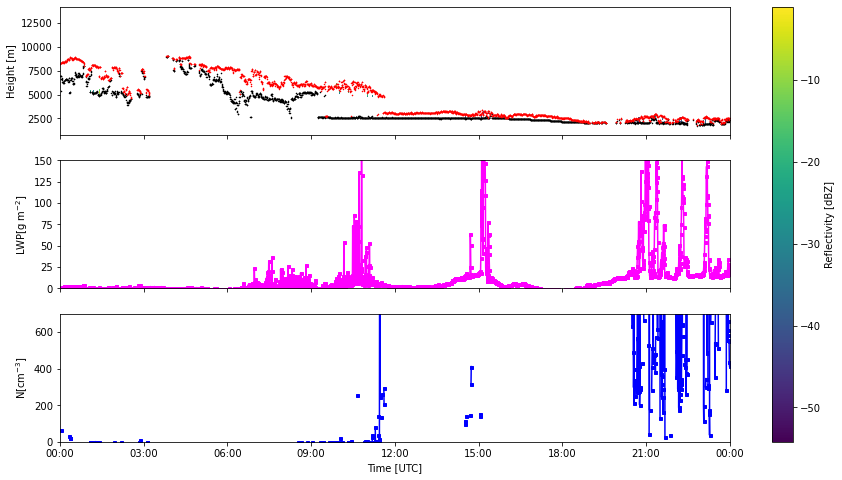

In [30]:
fig, axs = plt.subplots(3, sharex=True, figsize=(15, 8))

f1 = axs[0].pcolormesh(ze_liquid.index, 
                        ze_liquid.columns, 
                        np.transpose(ze_liquid),
                        cmap='viridis')
f2 = axs[0].plot(dfnew_cb, "*", color='black', markersize=1)
f3 = axs[0].plot(dfnew_ct, "*", color='red', markersize=1)

axs[0].set_ylabel(r'Height [m]')
fig.colorbar(f1, ax=axs[0:3],  label='Reflectivity [dBZ]')
#axs[0].set_ylim([1000,2300])

f4 = axs[1].plot(dfnew_lwp, "-s", color='magenta', markersize=3, markerfacecolor='magenta')

axs[1].set_ylabel(r'LWP[g m$^{-2}$]')
axs[1].set_ylim([0,150])

f5 = axs[2].plot(num_mh, "-s", color='blue', markersize=3)

axs[2].set_ylabel(r'N[cm$^{-3}$]')
axs[2].set_xlabel(r'Time [UTC]')
#axs[2].xaxis.set_major_locator(mdates.MinuteLocator(interval = 30))
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
#axs[2].set_xlim([datetime.datetime(2021, 4, 29, 10), datetime.datetime(2021, 4, 29, 15)])
axs[2].set_ylim([0,700])
plt.show()

In [ ]:
dfnew_lwp